# GSoC 2026 — PrediCT Project 3
## Part 2: Coronary Atlas Registration — Validation Notebook
**Author:** Ubadah Tanveer  
**Experiment:** Experiment 3 — ImageCAS Scan 50 Atlas → 30 COCA NCCT Scans  
**Target:** >70% calcium voxels within ±10mm of registered vessel zones

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import distance_transform_edt

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE        = Path(r'...\COCA_output')
EXP3        = BASE / 'experiment3_output'
RESAMPLED   = BASE / 'data_resampled'
REG_CSV     = EXP3 / 'registration_results.csv'
VAL_CSV     = EXP3 / 'validation_results.csv'

CAT_COLORS  = {'Minimal': '#60a5fa', 'Mild': '#34d399', 'Moderate': '#f59e0b', 'Severe': '#f87171'}
THRESHOLD   = 10.0  # mm
TARGET_PCT  = 70.0

# Load results
reg_df = pd.read_csv(REG_CSV)
val_df = pd.read_csv(VAL_CSV)
ok     = val_df[val_df['status'] == 'success'].copy()

print(f'Registration results : {len(reg_df)} scans')
print(f'Validation results   : {len(ok)} scans')
print(f'Atlas used           : ImageCAS Scan 50')
print(f'Distance threshold   : ±{THRESHOLD}mm')

Registration results : 30 scans
Validation results   : 30 scans
Atlas used           : ImageCAS Scan 50
Distance threshold   : ±10.0mm


## 1. Registration Summary

In [2]:
reg_ok = reg_df[reg_df['status'] == 'success']
print('='*55)
print('REGISTRATION SUMMARY')
print('='*55)
print(f'  Total scans        : {len(reg_df)}')
print(f'  Successful         : {len(reg_ok)} / {len(reg_df)} (100%)')
print(f'  Mean time/scan     : {reg_ok["total_time_s"].mean():.1f}s')
print(f'  Median time/scan   : {reg_ok["total_time_s"].median():.1f}s')
print(f'  Min time           : {reg_ok["total_time_s"].min():.1f}s')
print(f'  Max time           : {reg_ok["total_time_s"].max():.1f}s')
print(f'  Total time         : {reg_ok["total_time_s"].sum()/60:.1f} minutes')
print(f'  Mean MI metric     : {reg_ok["final_metric"].mean():.4f}')
print()
print('Per-category timing:')
for cat in ['Minimal','Mild','Moderate','Severe']:
    c = reg_ok[reg_ok['category']==cat]
    print(f'  {cat:<12}: n={len(c)}  mean={c["total_time_s"].mean():.1f}s  '
          f'metric={c["final_metric"].mean():.4f}')

REGISTRATION SUMMARY
  Total scans        : 30
  Successful         : 30 / 30 (100%)
  Mean time/scan     : 22.1s
  Median time/scan   : 19.9s
  Min time           : 13.0s
  Max time           : 65.0s
  Total time         : 11.1 minutes
  Mean MI metric     : -0.2189

Per-category timing:
  Minimal     : n=7  mean=20.8s  metric=-0.2222
  Mild        : n=7  mean=17.8s  metric=-0.2209
  Moderate    : n=7  mean=27.4s  metric=-0.2143
  Severe      : n=9  mean=22.5s  metric=-0.2185


## 2. Registration Timing Distribution

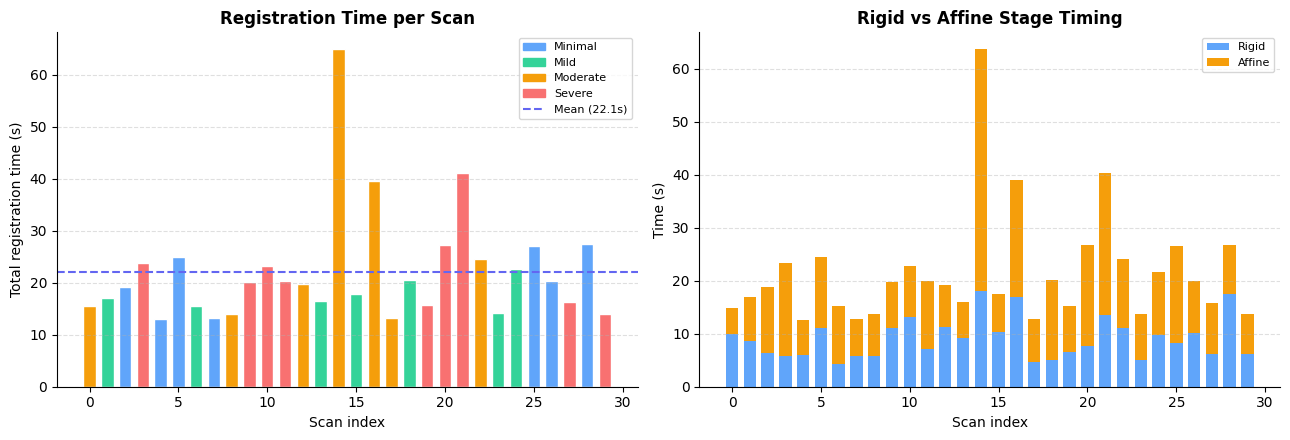

Rigid mean:  9.1s (41%)
Affine mean: 12.5s (57%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('white')

# Panel 1: timing per scan
ax = axes[0]
colors = [CAT_COLORS[c] for c in reg_ok['category']]
ax.bar(range(len(reg_ok)), reg_ok['total_time_s'], color=colors, edgecolor='white', width=0.7)
ax.axhline(reg_ok['total_time_s'].mean(), color='#6366f1', linewidth=1.5,
           linestyle='--', label=f'Mean ({reg_ok["total_time_s"].mean():.1f}s)')
ax.set_xlabel('Scan index'); ax.set_ylabel('Total registration time (s)')
ax.set_title('Registration Time per Scan', fontweight='bold')
ax.legend(fontsize=8)
handles = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in CAT_COLORS]
ax.legend(handles=handles + [plt.Line2D([0],[0],color='#6366f1',linestyle='--',
          label=f'Mean ({reg_ok["total_time_s"].mean():.1f}s)')], fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Panel 2: rigid vs affine breakdown
ax = axes[1]
x = range(len(reg_ok))
ax.bar(x, reg_ok['rigid_time_s'], color='#60a5fa', label='Rigid', width=0.7)
ax.bar(x, reg_ok['affine_time_s'], bottom=reg_ok['rigid_time_s'],
       color='#f59e0b', label='Affine', width=0.7)
ax.set_xlabel('Scan index'); ax.set_ylabel('Time (s)')
ax.set_title('Rigid vs Affine Stage Timing', fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(str(EXP3 / 'nb_timing.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Rigid mean:  {reg_ok["rigid_time_s"].mean():.1f}s ({100*reg_ok["rigid_time_s"].mean()/reg_ok["total_time_s"].mean():.0f}%)')
print(f'Affine mean: {reg_ok["affine_time_s"].mean():.1f}s ({100*reg_ok["affine_time_s"].mean()/reg_ok["total_time_s"].mean():.0f}%)')

## 3. Validation Summary

In [4]:
passed = ok[ok['percentage_10mm'] >= TARGET_PCT]
print('='*55)
print('VALIDATION SUMMARY')
print('='*55)
print(f'  Scans validated      : {len(ok)}')
print(f'  Passing >70%         : {len(passed)} / {len(ok)} ({100*len(passed)/len(ok):.0f}%)')
print(f'  Mean % within 10mm   : {ok["percentage_10mm"].mean():.1f}%')
print(f'  Median % within 10mm : {ok["percentage_10mm"].median():.1f}%')
print(f'  Min % within 10mm    : {ok["percentage_10mm"].min():.1f}%')
print(f'  Max % within 10mm    : {ok["percentage_10mm"].max():.1f}%')
print(f'  Mean dist to vessel  : {ok["dist_mean_mm"].mean():.1f}mm')
print(f'  Median dist          : {ok["dist_mean_mm"].median():.1f}mm')
print()
print('Per-category breakdown:')
for cat in ['Minimal','Mild','Moderate','Severe']:
    c = ok[ok['category']==cat]
    cp = (c['percentage_10mm'] >= TARGET_PCT).sum()
    print(f'  {cat:<12}: {cp}/{len(c)} pass  '
          f'mean={c["percentage_10mm"].mean():.1f}%  '
          f'dist={c["dist_mean_mm"].mean():.1f}mm')

VALIDATION SUMMARY
  Scans validated      : 30
  Passing >70%         : 17 / 30 (57%)
  Mean % within 10mm   : 68.5%
  Median % within 10mm : 71.6%
  Min % within 10mm    : 0.0%
  Max % within 10mm    : 100.0%
  Mean dist to vessel  : 8.3mm
  Median dist          : 7.7mm

Per-category breakdown:
  Minimal     : 6/7 pass  mean=85.7%  dist=5.6mm
  Mild        : 5/7 pass  mean=78.8%  dist=5.9mm
  Moderate    : 2/7 pass  mean=54.6%  dist=10.7mm
  Severe      : 4/9 pass  mean=58.0%  dist=10.2mm


## 4. Validation Score per Scan

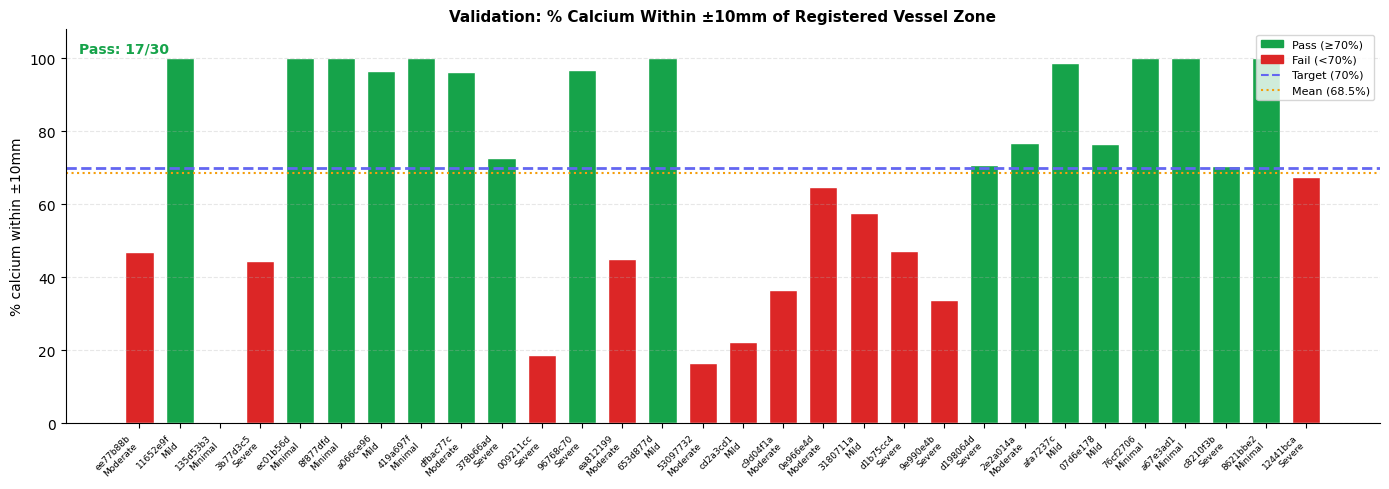

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')

colors = ['#16a34a' if p >= TARGET_PCT else '#dc2626' for p in ok['percentage_10mm']]
bars = ax.bar(range(len(ok)), ok['percentage_10mm'], color=colors, edgecolor='white', width=0.7)
ax.axhline(TARGET_PCT, color='#6366f1', linewidth=2, linestyle='--',
           label=f'Target ({TARGET_PCT:.0f}%)')
ax.axhline(ok['percentage_10mm'].mean(), color='#f59e0b', linewidth=1.5,
           linestyle=':', label=f'Mean ({ok["percentage_10mm"].mean():.1f}%)')

# x labels: scan_id shortened + category
labels = [f'{r.scan_id[:8]}\n{r.category}' for _, r in ok.iterrows()]
ax.set_xticks(range(len(ok)))
ax.set_xticklabels(labels, fontsize=6.5, rotation=45, ha='right')
ax.set_ylabel('% calcium within ±10mm', fontsize=10)
ax.set_title('Validation: % Calcium Within ±10mm of Registered Vessel Zone',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 108)

handles = [mpatches.Patch(color='#16a34a', label='Pass (≥70%)'),
           mpatches.Patch(color='#dc2626', label='Fail (<70%)'),
           plt.Line2D([0],[0], color='#6366f1', linestyle='--', label=f'Target (70%)'),
           plt.Line2D([0],[0], color='#f59e0b', linestyle=':', label=f'Mean ({ok["percentage_10mm"].mean():.1f}%)')]
ax.legend(handles=handles, fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

pass_count = (ok['percentage_10mm'] >= TARGET_PCT).sum()
ax.text(0.01, 0.97, f'Pass: {pass_count}/{len(ok)}',
        transform=ax.transAxes, va='top', fontsize=10, fontweight='bold',
        color='#16a34a')

plt.tight_layout()
plt.savefig(str(EXP3 / 'nb_validation_bars.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Per-Category Analysis

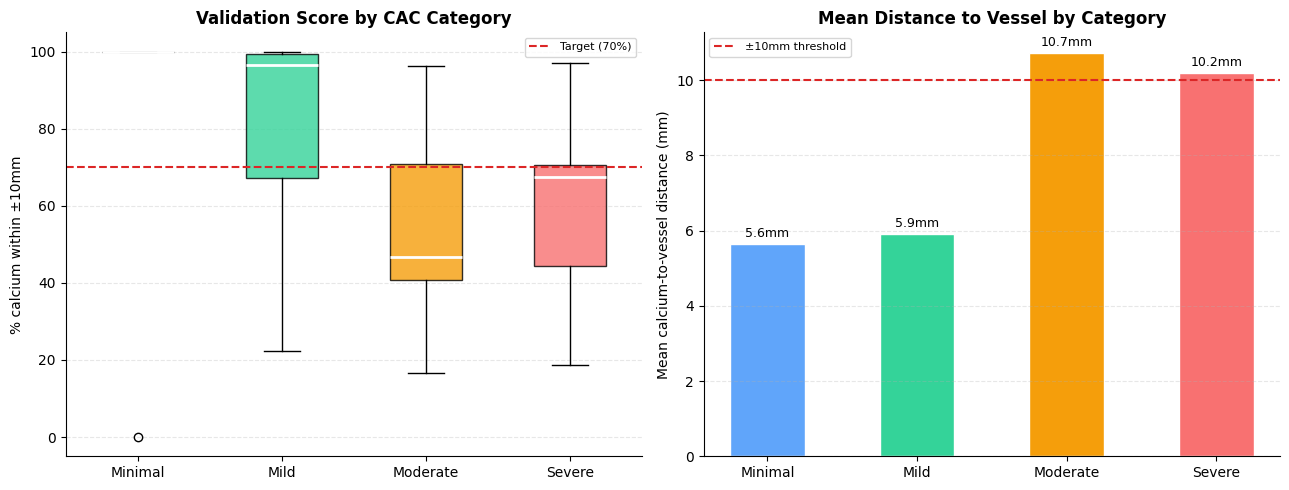

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
categories = ['Minimal', 'Mild', 'Moderate', 'Severe']

# Panel 1: boxplot per category
ax = axes[0]
data = [ok[ok['category']==c]['percentage_10mm'].values for c in categories]
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, cat in zip(bp['boxes'], categories):
    patch.set_facecolor(CAT_COLORS[cat])
    patch.set_alpha(0.8)
ax.axhline(TARGET_PCT, color='#dc2626', linewidth=1.5, linestyle='--',
           label=f'Target ({TARGET_PCT:.0f}%)')
ax.set_xticklabels(categories)
ax.set_ylabel('% calcium within ±10mm')
ax.set_title('Validation Score by CAC Category', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: mean distance per category
ax = axes[1]
means = [ok[ok['category']==c]['dist_mean_mm'].mean() for c in categories]
bars  = ax.bar(categories, means, color=[CAT_COLORS[c] for c in categories],
               edgecolor='white', width=0.5)
ax.axhline(THRESHOLD, color='#dc2626', linewidth=1.5, linestyle='--',
           label=f'±{THRESHOLD:.0f}mm threshold')
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}mm', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean calcium-to-vessel distance (mm)')
ax.set_title('Mean Distance to Vessel by Category', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(EXP3 / 'nb_category.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Registration Quality vs Validation Score

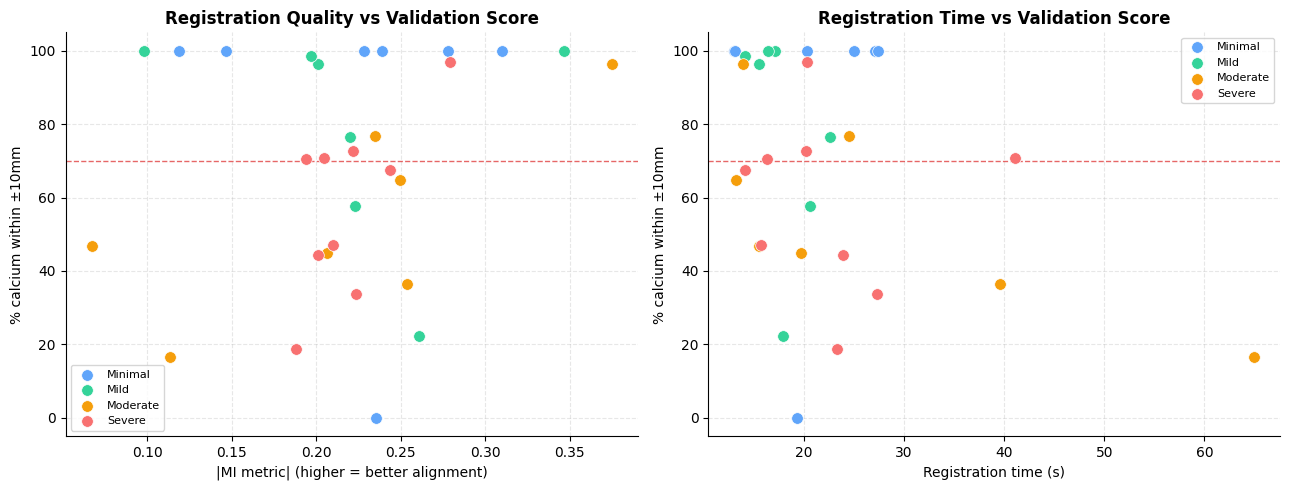

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Panel 1: MI metric vs validation %
ax = axes[0]
for cat in categories:
    c = ok[ok['category']==cat]
    ax.scatter(c['final_metric'].abs(), c['percentage_10mm'],
               c=CAT_COLORS[cat], label=cat, s=70, edgecolors='white',
               linewidths=0.5, zorder=3)
ax.axhline(TARGET_PCT, color='#dc2626', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xlabel('|MI metric| (higher = better alignment)')
ax.set_ylabel('% calcium within ±10mm')
ax.set_title('Registration Quality vs Validation Score', fontweight='bold')
ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: registration time vs validation %
ax = axes[1]
for cat in categories:
    c = ok[ok['category']==cat]
    ax.scatter(c['total_time_s'], c['percentage_10mm'],
               c=CAT_COLORS[cat], label=cat, s=70, edgecolors='white',
               linewidths=0.5, zorder=3)
ax.axhline(TARGET_PCT, color='#dc2626', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xlabel('Registration time (s)')
ax.set_ylabel('% calcium within ±10mm')
ax.set_title('Registration Time vs Validation Score', fontweight='bold')
ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(EXP3 / 'nb_scatter.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Distance Distribution Analysis

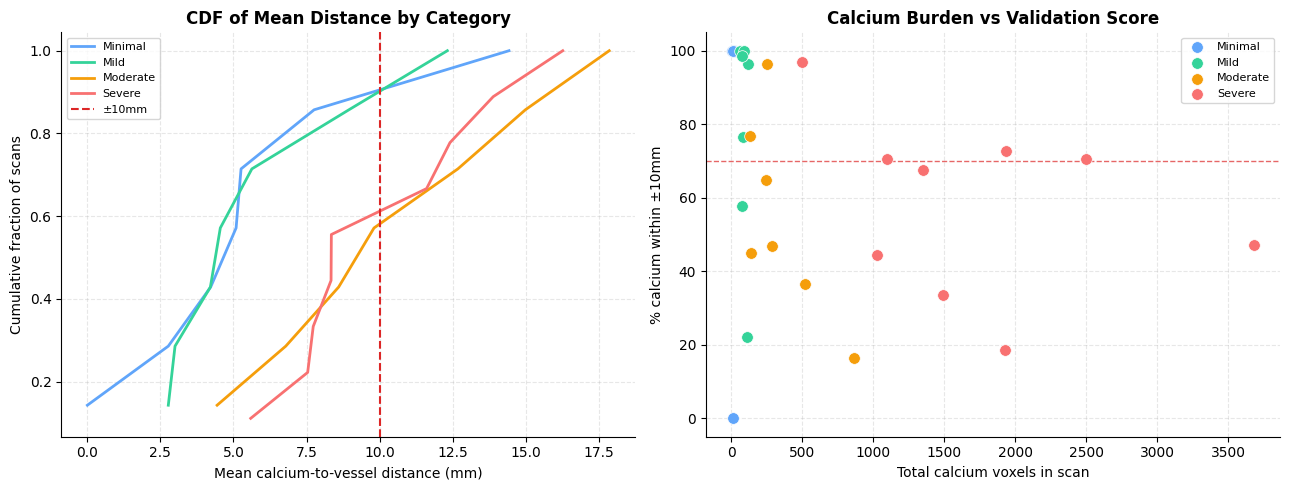

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Panel 1: distance CDF per category
ax = axes[0]
for cat in categories:
    c = ok[ok['category']==cat]
    means = c['dist_mean_mm'].values
    sorted_means = np.sort(means)
    cdf = np.arange(1, len(sorted_means)+1) / len(sorted_means)
    ax.plot(sorted_means, cdf, color=CAT_COLORS[cat], linewidth=2, label=cat)
ax.axvline(THRESHOLD, color='#dc2626', linewidth=1.5, linestyle='--',
           label=f'±{THRESHOLD:.0f}mm')
ax.set_xlabel('Mean calcium-to-vessel distance (mm)')
ax.set_ylabel('Cumulative fraction of scans')
ax.set_title('CDF of Mean Distance by Category', fontweight='bold')
ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: calcium voxel count vs validation %
ax = axes[1]
for cat in categories:
    c = ok[ok['category']==cat]
    ax.scatter(c['total_calcium'], c['percentage_10mm'],
               c=CAT_COLORS[cat], label=cat, s=70, edgecolors='white',
               linewidths=0.5, zorder=3)
ax.axhline(TARGET_PCT, color='#dc2626', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xlabel('Total calcium voxels in scan')
ax.set_ylabel('% calcium within ±10mm')
ax.set_title('Calcium Burden vs Validation Score', fontweight='bold')
ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(EXP3 / 'nb_distance.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## 8. Visual Overlays — Best and Worst Per Category

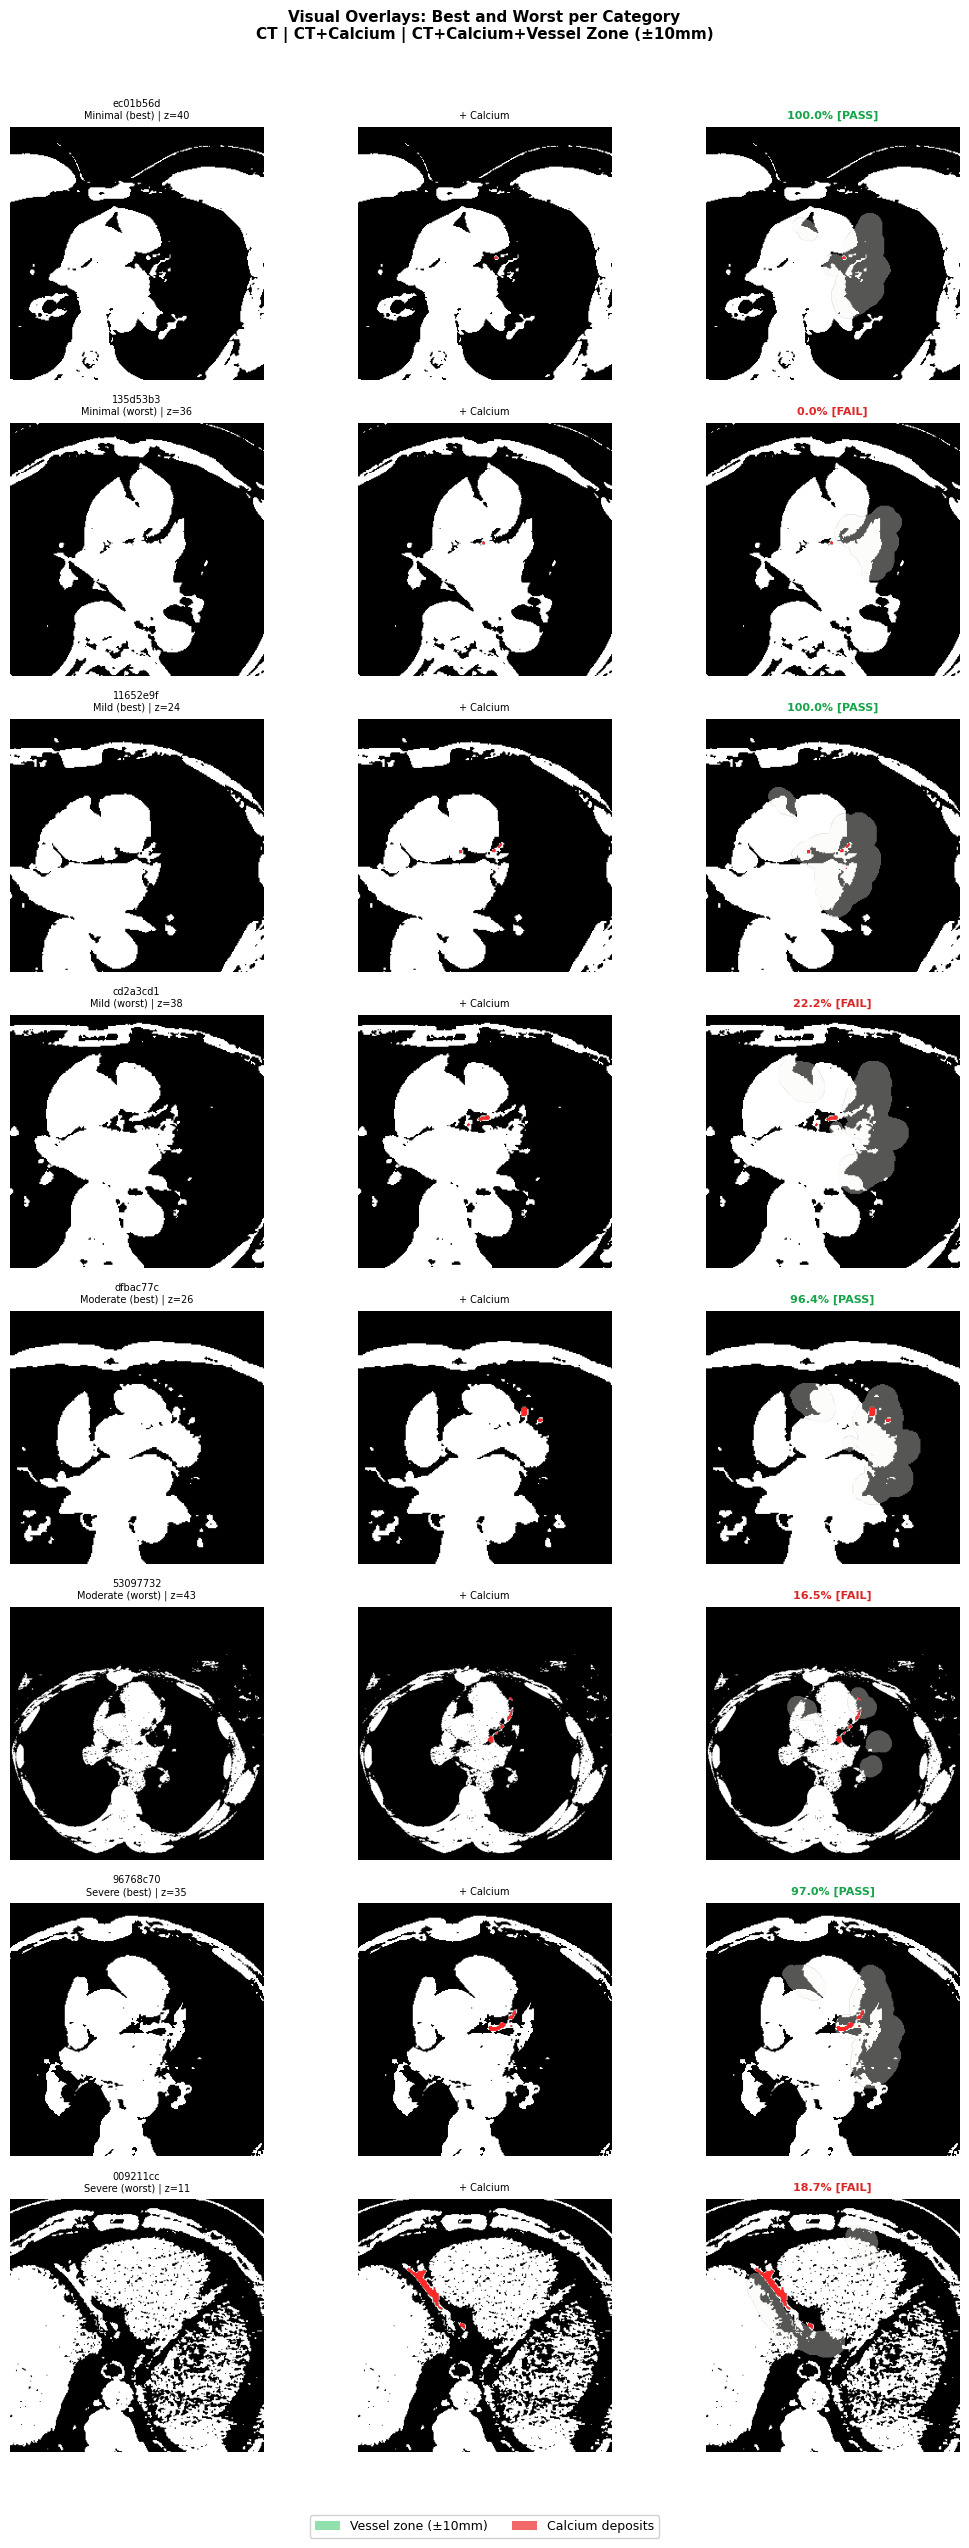

In [9]:
from scipy.ndimage import distance_transform_edt

def load_overlay_data(scan_id):
    img_path    = RESAMPLED / scan_id / f'{scan_id}_img.nii.gz'
    warped_path = EXP3 / 'registration' / scan_id / 'warped_atlas_seg.nii.gz'
    calcium_path = RESAMPLED / scan_id / f'{scan_id}_seg.nii.gz'

    ct   = sitk.GetArrayFromImage(sitk.ReadImage(str(img_path))).astype(np.float32)
    wseg = sitk.GetArrayFromImage(sitk.ReadImage(str(warped_path))).astype(np.uint8)
    cseg = sitk.GetArrayFromImage(sitk.ReadImage(str(calcium_path))).astype(np.uint8)

    # Align shapes
    ms = tuple(min(a,b) for a,b in zip(ct.shape, cseg.shape))
    ct   = ct[:ms[0],:ms[1],:ms[2]]
    wseg = wseg[:ms[0],:ms[1],:ms[2]]
    cseg = cseg[:ms[0],:ms[1],:ms[2]]

    # Best slice = most calcium
    best_z = int(cseg.sum(axis=(1,2)).argmax()) if cseg.sum() > 0 else ct.shape[0]//2

    img_s  = sitk.ReadImage(str(img_path))
    sp     = list(img_s.GetSpacing())
    dist   = distance_transform_edt(1 - wseg, sampling=[sp[2],sp[1],sp[0]])
    zone   = (dist <= THRESHOLD).astype(np.uint8)

    return ct[best_z], wseg[best_z], cseg[best_z], zone[best_z], best_z

def plot_overlay_row(ax_ct, ax_ca, ax_zone, scan_id, category, pct, z):
    ct_s, ws, cs, zs, _ = load_overlay_data(scan_id)
    ct_norm = np.clip(ct_s, 0, 1)
    for ax in [ax_ct, ax_ca, ax_zone]:
        ax.imshow(ct_norm, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    if cs.max() > 0:
        ax_ca.imshow(np.ma.masked_where(cs==0, cs), cmap='autumn', alpha=0.85)
    if zs.max() > 0:
        ax_zone.imshow(np.ma.masked_where(zs==0, zs), cmap='Greens', alpha=0.35)
    if cs.max() > 0:
        ax_zone.imshow(np.ma.masked_where(cs==0, cs), cmap='autumn', alpha=0.85)
    color  = '#16a34a' if pct >= TARGET_PCT else '#dc2626'
    status = 'PASS' if pct >= TARGET_PCT else 'FAIL'
    ax_ct.set_title(f'{scan_id[:8]}\n{category} | z={z}', fontsize=7)
    ax_ca.set_title(f'+ Calcium', fontsize=7)
    ax_zone.set_title(f'{pct:.1f}% [{status}]', fontsize=8, fontweight='bold', color=color)

# Select best and worst per category
selected = []
for cat in categories:
    c = ok[ok['category']==cat].sort_values('percentage_10mm', ascending=False)
    if len(c) >= 1: selected.append(('best', c.iloc[0]))
    if len(c) >= 2: selected.append(('worst', c.iloc[-1]))

fig, axes = plt.subplots(len(selected), 3, figsize=(11, 3.2*len(selected)))
fig.patch.set_facecolor('white')
fig.suptitle('Visual Overlays: Best and Worst per Category\n'
             'CT | CT+Calcium | CT+Calcium+Vessel Zone (±10mm)',
             fontsize=11, fontweight='bold')

for i, (label, row) in enumerate(selected):
    _, _, _, _, z = load_overlay_data(row.scan_id)
    plot_overlay_row(axes[i,0], axes[i,1], axes[i,2],
                     row.scan_id, f'{row.category} ({label})',
                     row.percentage_10mm, z)
    axes[i,0].set_ylabel(f'{label.upper()}', fontsize=8, fontweight='bold',
                         color='#16a34a' if label=='best' else '#dc2626', rotation=90)

leg = [mpatches.Patch(facecolor='#22c55e', alpha=0.5, label=f'Vessel zone (±{THRESHOLD:.0f}mm)'),
       mpatches.Patch(facecolor='#ef4444', alpha=0.8, label='Calcium deposits')]
fig.legend(handles=leg, loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), framealpha=0.9)
plt.tight_layout(rect=[0,0.02,1,0.97])
plt.savefig(str(EXP3 / 'nb_overlays.png'), dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Experiment Comparison: Exp 1 (Scan 100) vs Exp 3 (Scan 50)

In [10]:
comparison = {
    'Metric': ['Scans registered', 'Success rate', 'Passing >70%', 'Mean % ≤10mm',
               'Median % ≤10mm', 'Mean dist (mm)', 'Time/scan (s)', 'Total time (min)'],
    'Exp 1 — Scan 100': ['24/25', '96%', '8/25 (32%)', '50.4%',
                          '44.0%', '12.9mm', '15.7s', '6.3 min'],
    'Exp 3 — Scan 50':  ['30/30', '100%', '17/30 (57%)', f'{ok["percentage_10mm"].mean():.1f}%',
                          f'{ok["percentage_10mm"].median():.1f}%',
                          f'{ok["dist_mean_mm"].mean():.1f}mm',
                          f'{reg_ok["total_time_s"].mean():.1f}s',
                          f'{reg_ok["total_time_s"].sum()/60:.1f} min'],
}
comp_df = pd.DataFrame(comparison)
comp_df = comp_df.set_index('Metric')
print(comp_df.to_string())
print(f'\nImprovement in mean %: +{ok["percentage_10mm"].mean()-50.4:.1f}%')
print(f'Improvement in median: +{ok["percentage_10mm"].median()-44.0:.1f}%')

                 Exp 1 — Scan 100 Exp 3 — Scan 50
Metric                                           
Scans registered            24/25           30/30
Success rate                  96%            100%
Passing >70%           8/25 (32%)     17/30 (57%)
Mean % ≤10mm                50.4%           68.5%
Median % ≤10mm              44.0%           71.6%
Mean dist (mm)             12.9mm           8.3mm
Time/scan (s)               15.7s           22.1s
Total time (min)          6.3 min        11.1 min

Improvement in mean %: +18.1%
Improvement in median: +27.6%


## 10. Registration Parameters Reference

In [11]:
params = {
    'Atlas'                    : 'ImageCAS Scan 50 (CCTA, resampled to 0.7×0.7×3.0mm)',
    'Tool'                     : 'SimpleITK 2.x',
    'Stages'                   : 'Rigid (6 DOF) → Affine (12 DOF)',
    'Metric'                   : 'Mattes Mutual Information',
    'Histogram bins'           : 50,
    'Sampling strategy'        : 'RANDOM, 10%, seed=42',
    'Optimizer'                : 'GradientDescentLineSearch',
    'Learning rate'            : 1.0,
    'Iterations per level'     : 100,
    'Convergence min value'    : 1e-6,
    'Convergence window'       : 10,
    'Shrink factors'           : '[4, 2, 1]',
    'Smoothing sigmas (mm)'    : '[2.0, 1.0, 0.0]',
    'Initialization'           : 'CenteredTransformInitializer (MOMENTS)',
    'Max retries per scan'     : 3,
    'HU window (COCA)'         : '[-100, 900] → [0, 1]',
    'HU window (atlas)'        : '[-100, 900] → [0, 1]',
    'Target spacing (mm)'      : '0.7 × 0.7 × 3.0',
    'Validation threshold'     : '±10mm (Euclidean Distance Transform)',
    'Target pass rate'         : '>70% calcium voxels within threshold',
}
print('REGISTRATION PARAMETERS')
print('='*60)
for k, v in params.items():
    print(f'  {k:<30} : {v}')

REGISTRATION PARAMETERS
  Atlas                          : ImageCAS Scan 50 (CCTA, resampled to 0.7×0.7×3.0mm)
  Tool                           : SimpleITK 2.x
  Stages                         : Rigid (6 DOF) → Affine (12 DOF)
  Metric                         : Mattes Mutual Information
  Histogram bins                 : 50
  Sampling strategy              : RANDOM, 10%, seed=42
  Optimizer                      : GradientDescentLineSearch
  Learning rate                  : 1.0
  Iterations per level           : 100
  Convergence min value          : 1e-06
  Convergence window             : 10
  Shrink factors                 : [4, 2, 1]
  Smoothing sigmas (mm)          : [2.0, 1.0, 0.0]
  Initialization                 : CenteredTransformInitializer (MOMENTS)
  Max retries per scan           : 3
  HU window (COCA)               : [-100, 900] → [0, 1]
  HU window (atlas)              : [-100, 900] → [0, 1]
  Target spacing (mm)            : 0.7 × 0.7 × 3.0
  Validation threshold        

## 11. Full Results Table

In [12]:
display_cols = ['scan_id','category','total_calcium','within_10mm',
                'percentage_10mm','dist_mean_mm','passes_target','total_time_s','final_metric']
display_df = ok[display_cols].copy()
display_df.columns = ['Scan ID','Category','Ca Voxels','Within 10mm',
                       '% ≤10mm','Mean Dist (mm)','Pass','Time (s)','MI Metric']
display_df['Pass'] = display_df['Pass'].map({True: '✅', False: '❌'})
display_df = display_df.sort_values('Category')

pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)
print(display_df.to_string(index=False))

     Scan ID Category  Ca Voxels  Within 10mm  % ≤10mm  Mean Dist (mm) Pass  Time (s)  MI Metric
11652e9fb31c     Mild         59           59   100.00            3.00    ✅     17.11      -0.35
a066ce96b52f     Mild        113          109    96.46            4.55    ✅     15.55      -0.20
cd2a3cd1c2da     Mild        108           24    22.22           12.32    ❌     17.86      -0.26
07d6e17850f2     Mild         81           62    76.54            5.63    ✅     22.64      -0.22
afa7237cd394     Mild         74           73    98.65            4.21    ✅     14.10      -0.20
3180711a23a0     Mild         71           41    57.75            8.95    ❌     20.58      -0.22
653d877d5833     Mild         90           90   100.00            2.77    ✅     16.42      -0.10
76cf2706f8f8  Minimal         24           24   100.00            4.22    ✅     27.14      -0.15
135d53b39cad  Minimal         10            0     0.00           14.43    ❌     19.27      -0.24
a67e3ad1f932  Minimal         